### Overview

We are now ready to perform a large computation to create a median composite image for a city using XArray and Dask, leveraging STAC and DuckDB for querying cloud-hosted data sources.

### Overview of the Task

We will query the Overture Maps catalog for the boundary for the city of Bengaluru, India, use it to query a STAC catalog for Sentinel-2 imagery for a chosen period and then use XArray and Dask to create a median composite image using distributed processing.


### Setup

In [ ]:
%%capture
if 'google.colab' in str(get_ipython()):
    !pip install pystac-client odc-stac rioxarray dask['distributed']

In [ ]:
from odc.stac import stac_load
import geopandas as gpd
import matplotlib.pyplot as plt
import os
import pystac_client
import rioxarray as rxr
import xarray as xr
import duckdb

In [ ]:
data_folder = 'data'
output_folder = 'output'

if not os.path.exists(data_folder):
    os.mkdir(data_folder)
if not os.path.exists(output_folder):
    os.mkdir(output_folder)

Setup a local Dask cluster. This distributes the computation across multiple workers on your computer.

In [ ]:
from dask.distributed import Client
client = Client()  # set up local cluster on the machine
client

If you are running this notebook in Colab, you will need to create and use a proxy URL to see the dashboard running on the local server.

In [ ]:
if 'google.colab' in str(get_ipython()):
    from google.colab import output
    port_to_expose = 8787  # This is the default port for Dask dashboard
    print(output.eval_js(f'google.colab.kernel.proxyPort({port_to_expose})'))


### Search and Load City Boundary

Read the file containing the city boundary.

We initialize DuckDB and enable the spatial extension.

In [ ]:
con = duckdb.connect()
con.install_extension('spatial')
con.load_extension('spatial')

In [ ]:
country_iso2 = 'IN'
city_name = 'Bengaluru'
region = 'IN-KA'

In [ ]:
# Overture does monthly releases of their dataset
# Find the latest release at https://stac.overturemaps.org/
OVERTURE_RELEASE = '2026-04-15.0'

s3_path = (
        f's3://overturemaps-us-west-2/release/{OVERTURE_RELEASE}/'
        'theme=divisions/type=division_area/*'
    )

query = f'''
  SELECT
      id,
      names.primary AS name,
      subtype,
      country,
      region,
      ST_AsText(geometry) AS geometry
  FROM read_parquet(
      '{s3_path}',
      filename=true,
      hive_partitioning=1
  )
  WHERE subtype in ('locality', 'county', 'localadmin', 'region') AND
  country = '{country_iso2}' AND
  region = '{region}' AND
  names.primary ILIKE '{city_name}'
  AND is_land = true          -- exclude maritime extensions
  ORDER BY
    -- prefer 'locality' over other types
    CASE subtype WHEN 'locality' THEN 0 ELSE 1 END
  LIMIT 1
'''

results = con.sql(query).df()
results

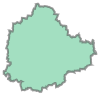

In [43]:
city_gdf = gpd.GeoDataFrame(
    results, geometry=gpd.GeoSeries.from_wkt(results.geometry), crs='EPSG:4326'
)

geometry = city_gdf.geometry.union_all()
geometry

### Search and Load Sentinel-2 Imagery

Let's use Element84 search endpoint to look for items from the `sentinel-2-c1-l2a` collection on AWS. We search for the imagery collected within the date range and intersecting the AOI geometry.

We also specify additonal filters to select scenes based on metadata. The parameter `eo:cloud_cover` contains the overall cloud percentage and we use it to select imagery with < 30% overall cloud cover.

In [ ]:
catalog = pystac_client.Client.open(
    'https://earth-search.aws.element84.com/v1')

# Search for images for the year
year = 2024
time_range = f'{year}'

# Optionally, we can specify a range of months
# start_month = 4
# end_month = 6
# time_range = f'{year}-{start_month:02d}/{year}-{end_month:02d}'

filters = {
    'eo:cloud_cover': {'lt': 30},
}

search = catalog.search(
    collections=['sentinel-2-c1-l2a'],
    intersects=geometry,
    datetime=time_range,
    query=filters,
)
items = search.item_collection()
len(items)

Visualize the resulting image footprints. You can see that our AOI covers only a small part of a single scene. When we process the data for our AOI - we will only stream the required pixels to create the composite instead of downloading entire scenes.

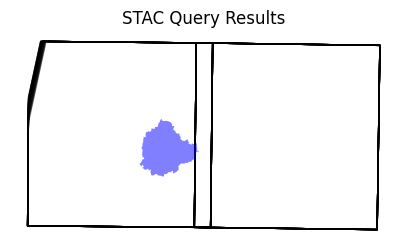

In [44]:
items_gdf = gpd.GeoDataFrame.from_features(items.to_dict(), crs='EPSG:4326')

fig, ax = plt.subplots(1, 1)
fig.set_size_inches(5,5)
items_gdf.plot(
    ax=ax,
    facecolor='none',
    edgecolor='black',
    alpha=0.5)

city_gdf.plot(
    ax=ax,
    facecolor='blue',
    alpha=0.5
)
ax.set_axis_off()
ax.set_title('STAC Query Results')
plt.show()

Load the matching images as a XArray Dataset.

In [ ]:
ds = stac_load(
    items,
    bands=['red', 'green', 'blue'],
    resolution=10,
    bbox=geometry.bounds,
    chunks={},  # <-- use Dask
    groupby='solar_day',
)
ds

The Sentinel-2 scenes come with NoData value of 0. So we set the correct NoData value before further processing.

In [ ]:
# Mask nodata values
ds = ds.where(ds != 0)

Apply scale and offset to all spectral bands

In [ ]:
# Apply scale/offset
scale = 0.0001
offset = -0.1
# Select spectral bands (all except 'scl')
data_bands = [band for band in ds.data_vars if band != 'scl']
for band in data_bands:
  ds[band] = ds[band] * scale + offset

Convert the Dataset it to a DataArray using the `to_array()` method. All the variables will be converted to a new dimension. Since our variables are image bands, we give the name of the new dimesion as `band`.

In [ ]:
da = ds.to_array('band')
da

### Create a Median Composite
A very-powerful feature of XArray is the ability to easily aggregate data across dimensions - making it ideal for many remote sensing analysis. Let’s create a median composite from all the individual images.

We apply the `.median()` aggregation across the time dimension.

In [ ]:
rgb_composite = da \
  .sel(band=['red', 'green', 'blue']) \
  .median(dim='time')
rgb_composite

So far all the operations that we have created a computation graph. To run this computation using the local Dask cluster, we must call `.compute()`.

In [ ]:
%%time
rgb_composite = rgb_composite.compute()

### Visualizing and Exporting the Results

The composite is creating from all the pixels within the bounding box of the geometry. We can use `rioxarray` to clip the image to the city boundary to remove pixels outside the polygon.

In [ ]:
image_crs = rgb_composite.rio.crs
city_gdf_reprojected = city_gdf.to_crs(image_crs)
rgb_composite_clipped = rgb_composite.rio.clip(city_gdf_reprojected.geometry)

Plot the results.

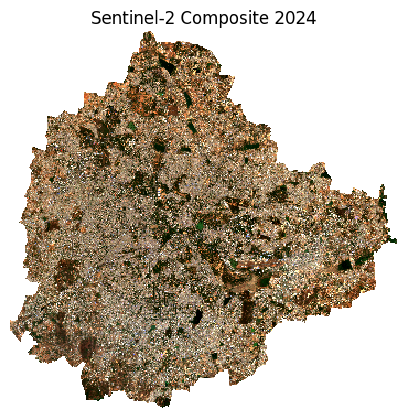

In [45]:
preview = rgb_composite_clipped.rio.reproject(
    rgb_composite_clipped.rio.crs, resolution=100
)

fig, ax = plt.subplots(1, 1)
fig.set_size_inches(5,5)
preview.sel(band=['red', 'green', 'blue']).plot.imshow(
    ax=ax,
    robust=True)
ax.set_title(f'Sentinel-2 Composite {year}')
ax.set_axis_off()
ax.set_aspect('equal')
plt.show()

We finally save the results as a local Cloud-Optimized GeoTIFF file.

Rather than saving it to the temporary machine where Colab is running, we can save it to our own Google Drive. This will ensure the image will be available to us even after existing Google Colab.

Run the following cell to authenticate and mount the Google Drive.

In [ ]:
if 'google.colab' in str(get_ipython()):
  from google.colab import drive
  drive.mount('/content/drive')

In [ ]:
if 'google.colab' in str(get_ipython()):
  drive_folder_root = 'MyDrive'
  output_folder = 'data'
  output_folder_path = os.path.join(
      '/content/drive', drive_folder_root, output_folder)

  # Check if Google Drive is mounted
  if not os.path.exists('/content/drive'):
      print("Google Drive is not mounted. Please run the cell above to mount your drive.")
  else:
      if not os.path.exists(output_folder_path):
          os.makedirs(output_folder_path)
else:
  # Use the local folder
  output_folder_path = output_folder

In [ ]:
output_file = f'composite_{time_range}.tif'
output_path = os.path.join(output_folder_path, output_file)
rgb_composite_clipped.rio.to_raster(output_path, driver='COG')
print(f'Wrote {output_file}')